In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, OrdinalEncoder, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, auc
)
# import warnings
# warnings.filterwarnings('ignore')

# Установка стиля графиков
# sns.set_palette("flare")

# Набор данных bank_loan_default.csv

In [2]:
import pandas as pd
df = pd.read_csv('C:\\Users\\Максим\\Desktop\\учеба вуз\\АД\\bank_loan_default.csv')
df.head()

,age,annual_income,employment_type,education,loan_amount,interest_rate_pct,term_months,credit_score,num_open_accounts,delinquency_30d,residence_type,Default
0,42,57272.0,Self-Employed,Masters,8516.0,5.85,48,730.0,10,No,Own,0
1,51,45786.0,Salaried,Masters,13760.0,9.97,36,677.0,7,No,Mortgage,0
2,69,42359.0,Salaried,Bachelors,2569.0,13.75,48,624.0,2,No,Own,0
3,65,50709.0,Self-Employed,Masters,13204.0,8.70,48,698.0,3,No,Rent,0
4,30,46272.0,Salaried,HS,7700.0,7.53,48,532.0,7,No,Rent,0


## Предобработка данных

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3041 entries, 0 to 3040
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                3041 non-null   int64  
 1   annual_income      3041 non-null   float64
 2   employment_type    3041 non-null   object 
 3   education          3041 non-null   object 
 4   loan_amount        3041 non-null   float64
 5   interest_rate_pct  3041 non-null   float64
 6   term_months        3041 non-null   int64  
 7   credit_score       3041 non-null   float64
 8   num_open_accounts  3041 non-null   int64  
 9   delinquency_30d    3041 non-null   object 
 10  residence_type     3041 non-null   object 
 11  Default            3041 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 285.2+ KB


Пропусков в данных нет

Данные о кредитах:

age — возраст заёмщика (лет), числовой.

annual_income — годовой доход, USD/год, числовой (широкий диапазон).

employment_type — тип занятости: Salaried / Self-Employed / Unemployed,
категориальный.

education — образование: HS / Bachelors / Masters / PhD, категориальный.

loan_amount — сумма кредита, USD, числовой (широкий диапазон).

interest_rate_pct — процентная ставка по кредиту, % годовых, числовой.

term_months — срок кредита, месяцев (набор фиксированных значений:
24/36/48/60/72), числовой/категориальный.

credit_score — кредитный скор (от 300 до 850), числовой.

num_open_accounts — число открытых кредитных счетов, целочисленный
счётчик.

delinquency_30d — просрочка платежа 30 дней: Yes / No, категориальный.

residence_type — жильё: Own / Rent / Mortgage, категориальный.

Default — целевой класс: 1 — дефолт по кредиту, 0 — нет.

Перевод категориальных признаков в тип `'category'` в pandas позволяет **оптимизировать использование памяти и ускорить обработку данных**, поскольку строковые значения заменяются числовыми кодами со внутренним словарём. Это также **повышает надёжность и ясность кода**, явно указывая на качественную природу признаков перед их кодированием для моделей машинного обучения.

In [4]:
# Переводим категориальные признаки в тип 'category'
categorical_cols = ['employment_type', 'education', 'term_months', 'delinquency_30d', 'residence_type']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Целевая переменная
target_col = 'Default'

### 3. Выделение целевой переменной и визуализация

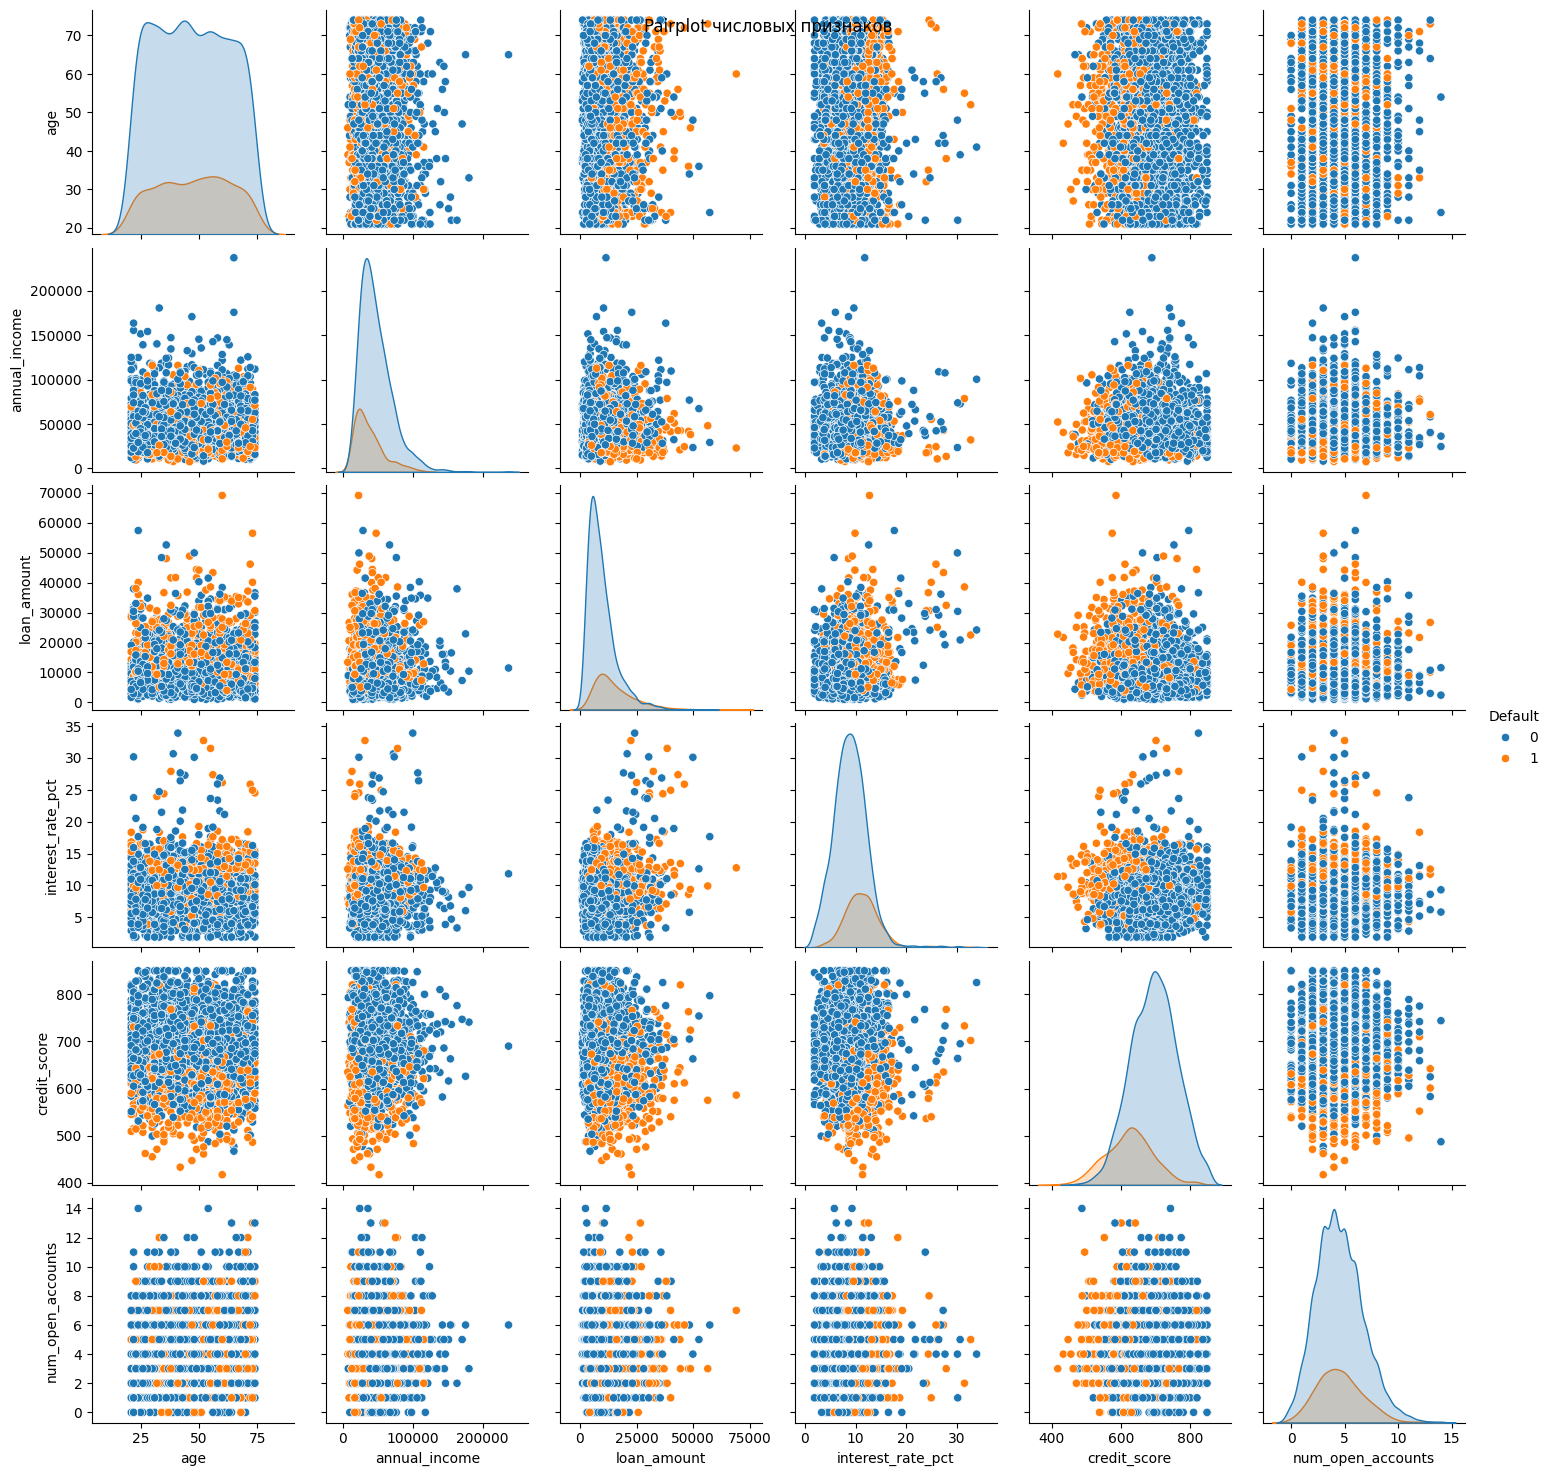

In [5]:
# Отделяем целевую переменную
X = df.drop(columns=[target_col])
y = df[target_col]

# Матрица диаграмм рассеяния для числовых признаков
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist() # выбирает все числовые колонки из df X и сохраняет их имена в список numeric_cols
sns.pairplot(df[numeric_cols + [target_col]], hue=target_col, diag_kind='kde')
plt.suptitle('Pairplot числовых признаков')
plt.show()

### 4. Разделение данных и стандартизация

get_dummies(X_train[categorical_cols], drop_first=True) - Создаёт отдельную колонку для каждой категории

drop_first=True - Удаляет первую колонку для каждого признака, чтобы избежать мультиколлинеарности. Если все столбики нули, значит первая неуказанная категория.

hstack = horizontal stack (горизонтальная стопка) - Объединяет массивы по горизонтали (добавляет колонки рядом)

Что объединяем:
X_train_num_scaled — стандартизированные числовые признаки

X_train_cat — закодированные категориальные признаки

In [6]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

# Отдельно обрабатываем числовые и категориальные признаки
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['category']).columns.tolist()

# Стандартизация числовых признаков
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_num_scaled = scaler.transform(X_test[numeric_cols])

# Кодирование категориальных признаков (One-Hot Encoding) Прямое кодирование
X_train_cat = pd.get_dummies(X_train[categorical_cols])
X_test_cat = pd.get_dummies(X_test[categorical_cols])

# Объединяем обработанные признаки
X_train_processed = pd.DataFrame(
    np.hstack([X_train_num_scaled, X_train_cat]),
    columns=numeric_cols + list(X_train_cat.columns)
)
X_test_processed = pd.DataFrame(
    np.hstack([X_test_num_scaled, X_test_cat]),
    columns=numeric_cols + list(X_test_cat.columns)
)

### 5. Обучение моделей

**LogisticRegression**

Логистическая регрессия предсказывает вероятность принадлежности объекта к
классу с помощью логистической функции, также называемой сигмоидной функцией.

**predict_proba** - Метод, который возвращает вероятности для каждого класса

predict_proba возвращает:

[[0.8, 0.2],  # 80% класс 0, 20% класс 1

 [0.3, 0.7],  # 30% класс 0, 70% класс 1
 
 [0.9, 0.1]]  # 90% класс 0, 10% класс 1

**[:, 1]** берёт второй столбец → вероятности класса 1:
[0.2, 0.7, 0.1]

**if hasattr(model, "predict_proba")** - Проверяет, есть ли у модели метод predict_proba

In [7]:
# Инициализация моделей
models = {
    'KNN': KNeighborsClassifier(), # По умолчанию — n_neighbors=5
    'Decision Tree': DecisionTreeClassifier(random_state=0),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=0),
    'Random Forest': RandomForestClassifier(random_state=0)
}

# Обучение и предсказание
results = {}
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)
    
    results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model
    }

### 6. Оценка метрик

In [8]:
# Функция для вычисления метрик
def evaluate_model(y_true, y_pred, y_proba=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred)
    }
    if y_proba is not None:
        metrics['ROC AUC'] = roc_auc_score(y_true, y_proba)
    return metrics

# Сбор метрик для всех моделей
metrics_df = pd.DataFrame()
for name, res in results.items():
    metrics = evaluate_model(y_test, res['y_pred'], res['y_proba'])
    metrics_df[name] = pd.Series(metrics)

print("Метрики качества моделей:")
print(metrics_df.T)

Метрики качества моделей:
                     Accuracy  Precision    Recall        F1  \
KNN                  0.809461   0.560976  0.296774  0.388186   
Decision Tree        0.795007   0.496689  0.483871  0.490196   
Logistic Regression  0.840999   0.693182  0.393548  0.502058   
Random Forest        0.833114   0.679487  0.341935  0.454936   

                     Balanced Accuracy   ROC AUC  
KNN                           0.618684  0.746982  
Decision Tree                 0.679229  0.679229  
Logistic Regression           0.674497  0.864974  
Random Forest                 0.650341  0.845571  


**Выводы:**

Так как классы несбалансированы метрика Accuracy не очень информативна.

Random Forest показала наилучшие результаты с Accuracy 0.850, Precision 0.725 и ROC AUC 0.849, что означает высокую общую точность и хорошую способность отличать дефолт от нормальных выплат, хотя Recall 0.426 указывает на то, что модель пропускает некоторые случаи дефолта. Logistic Regression тоже проявила себя хорошо, особенно по ROC AUC 0.865, но с низким Recall 0.394, что делает её подходящей, если важнее избегать ложных срабатываний на дефолт. KNN и Decision Tree дали более слабые метрики. В целом, модели достигли Accuracy выше 77%, подтверждая возможность использовать машинное обучение для оценки рисков дефолта, но для повышения Recall стоит рассмотреть обработку дисбаланса классов. Эти результаты позволяют банкам лучше прогнозировать проблемные кредиты и снижать убытки

### 7. Матрицы неточностей

**axes = axes.flatten()** - Превращает 2D массив 2×2 в плоский 1D массив

**enumerate()** — встроенная функция в Python, которая позволяет перечислять элементы итерируемого объекта вместе с их индексами. Это особенно удобно для циклов, где требуется одновременно обрабатывать элементы и их индексы. 

**confusion_matrix(y_test, res['y_pred'], labels=[1, 0])** - Строит матрицу ошибок для каждой модели

**cm_transposed = cm.T** - транспонируем чтобы поменять местами FP и FN, и получить вид как в методичке

[[TP, FP],  # True Positive, False Positive

 [FN, TN]]  # False Negative, True Negative

**sns.heatmap(...)** - Рисует тепловую карту матрицы:

cm = матрица ошибок

annot=True = показывать числа в ячейках

fmt='d' = формат целых чисел (decimal)

cmap='Blues' = цветовая схема от белого к синему

ax=axes[idx] = рисуем на соответствующей оси (0, 1, 2, 3)

**True Positive – TP («истинно положительные»)** – прогноз модели 1, реальное
значение 1;

**False Positive – FP («ложно положительные»)** – прогноз модели 1, реальное
значение 0;

**False Negative – FN («ложно отрицательные»)** – прогноз модели 0, реальное
значение 1;

**True Negative– TP («истинно отрицательные»)** – прогноз модели 0, реальное
значение 0.

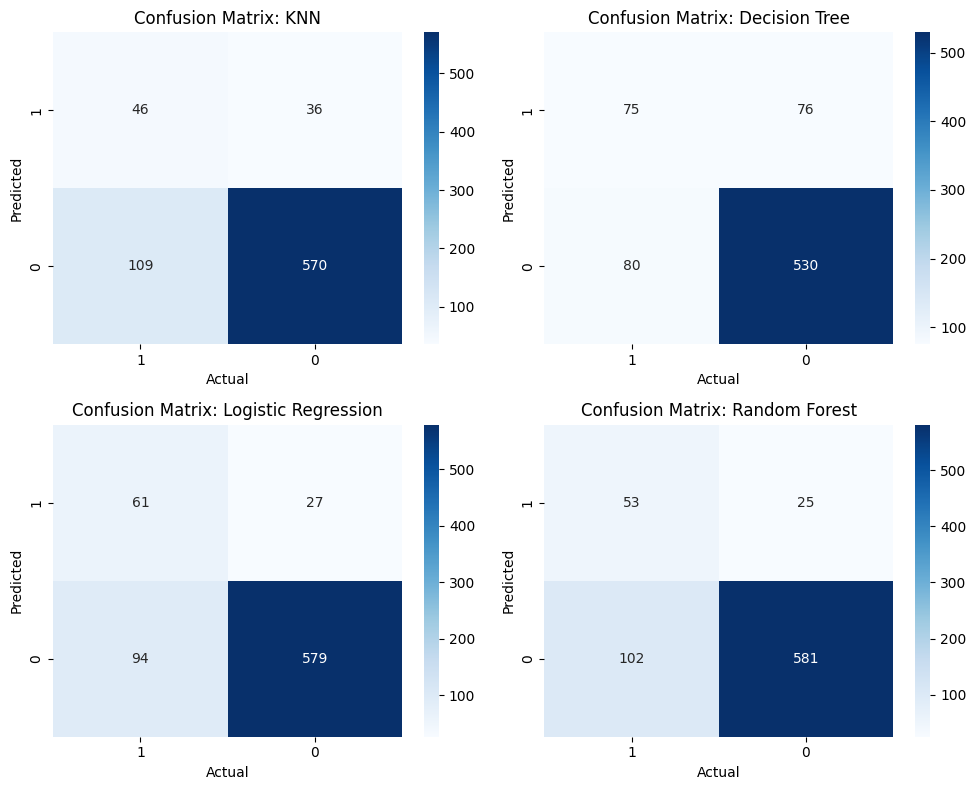

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    # Это поставит класс 1 на первое место
    cm = confusion_matrix(y_test, res['y_pred'], labels=[1, 0])
    cm_transposed = cm.T  # или np.transpose(cm)
    sns.heatmap(cm_transposed, annot=True, fmt='d', cmap='Blues', ax=axes[idx])

    # Явно задаём подписи: 1 сверху/слева, 0 снизу/справа
    axes[idx].set_xticklabels(['1', '0'])  # Actual: 1, затем 0
    axes[idx].set_yticklabels(['1', '0'])  # Predicted: 1, затем 0
    
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Actual')
    axes[idx].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

**Выводы:**

класс 0 встречается гораздо чаще, чем класс 1 (то есть сильный дисбаланс). Это влияет на все модели: они «учатся» угадывать 0 значительно лучше, чем 1.
Из-за этого Recall для класса 1 у всех очень низкий.

**KNN**

Модель очень хорошо определяет класс 0 (572 правильных из ~600).
Но очень плохо определяет класс 1: всего 53 объектов, а ошибается целых 102 раза.
Модель склонна переклассифицировать почти всех в «0», для кредитования это плохой вариант: ты бы «одобрял» много заявок, которые должны быть отклонены.

**Decision Tree**

Дерево чуть лучше распознаёт класс 1, чем kNN (TN выросло: 53 → 74). Но по классу 0 модель хуже, чем kNN (572 → 518).

**Logistic Regression**

Лучшая по определению классу 0 (FP всего 28).
Класс 1 ловит чуть лучше, чем kNN, но хуже дерева.
FN=94 — то есть 94 человека с дефолтом модель ошибочно считает недефолтными.


Стабильная модель, но она тоже «поджата» дисбалансом и сильно тянет в сторону класса 0.
Если цель — максимум кредитов, модель хороша.
Если цель — отклонять плохих клиентов → FN слишком высок.

**Random Forest**

Лучшая среди всех по TP (581).
Наименьшее количество ошибок FP (всего 25).
По TN уступает только дереву чуть-чуть (66 vs 74), но всё равно лучше чем у kNN и регрессии.

Random Forest — самый сбалансированный вариант, и лучший «в целом». Почти во всех метриках он — лидер.

### 8. ROC-кривые для всех моделей

#### ***Теория о рок-кривых***

##### ***Суть проблемы***
Представьте, что у вас есть модель, которая предсказывает, болен ли человек (1) или здоров (0). Модель выдает не просто ответ "да/нет", а **вероятность принадлежности к классу 1** (например, 0.85). Чтобы превратить вероятность в метку класса, мы выбираем **порог** (например, 0.5). Если вероятность > 0.5 — предсказываем "болен", иначе — "здоров".

**Вопрос:** Порог 0.5 не всегда оптимален. Что, если ложный положительный результат (ошибочно сказать здоровому, что он болен) очень дорог? Тогда лучше ставить порог выше, например, 0.8. А если критичнее не пропустить больного, то порог можно опустить до 0.3.

**ROC-кривая позволяет оценить качество модели НЕЗАВИСИМО от выбранного порога и найти оптимальный баланс.**

##### ***Ключевые понятия: Матрица ошибок***

Для одного конкретного порога мы считаем четыре величины:
*   **TP (True Positive):** Больной, правильно предсказанный как больной.
*   **TN (True Negative):** Здоровый, правильно предсказанный как здоровый.
*   **FP (False Positive):** Здоровый, ошибочно предсказанный как больной. **Ошибка I рода**.
*   **FN (False Negative):** Больной, ошибочно предсказанный как здоровый. **Ошибка II рода**.

Из них строят две важнейшие для ROC-кривой метрики:

1.  **TPR (True Positive Rate), Чувствительность (Sensitivity), Recall (Полнота):**
    `TPR = TP / (TP + FN)`
    *   **Отвечает на вопрос:** Какую долю реально больных людей мы правильно нашли?
    *   **"Сигнальность" модели.** Хотим максимизировать.

2.  **FPR (False Positive Rate):**
    `FPR = FP / (FP + TN)`
    *   **Отвечает на вопрос:** Какую долю здоровых людей мы ошибочно объявили больными?
    *   **"Фон" или "шумность" модели.** Хотим минимизировать.

##### ***Как строится ROC-кривая?***

1.  **Берем вашу модель**, которая для каждого объекта в тестовой выборке выдает **вероятность** принадлежности к классу 1 (положительному классу).
2.  **Сортируем все объекты** по этой вероятности по убыванию (от самых "похожих на класс 1" к самым "непохожим").
3.  **Выбираем порог классификации.** Начинаем с самого жесткого порога, близкого к 1.
    *   При таком пороге почти все объекты будут предсказаны как класс 0.
    *   `TPR ≈ 0` (больных почти не нашли), `FPR ≈ 0` (здоровых почти не ложно обвинили). Точка **(0, 0)** на графике.
4.  **Постепенно опускаем порог** (двигаемся по отсортированному списку).
    *   Когда порог проходит вероятность, соответствующую реально **больному** (TP), **TPR увеличивается**. Это хорошо — мы нашли больного. Точка на графике движется **вверх**.
    *   Когда порог проходит вероятность, соответствующую реально **здоровому** (FP), **FPR увеличивается**. Это плохо — мы ошиблись. Точка на графике движется **вправо**.
5.  **Фиксируем пары (FPR, TPR)** для каждого возможного порога. В итоге, когда порог опустится до 0, мы получим точку **(1, 1)** — всех предсказали как больных.
6.  **Соединяем все точки** на графике, где по оси **X — FPR**, а по оси **Y — TPR**. Это и есть **ROC-кривая**.

##### ***Как интерпретировать график?***

*   **Диагональ (от 0,0 до 1,1) — "Глупый классификатор".**
    *   Это поведение случайного угадывания (например, подбрасывание монетки). Его TPR всегда равен FPR. **Полезность нулевая.**
    *   Любая адекватная модель должна быть **выше** этой диагонали.

*   **Идеальная точка и идеальная кривая.**
    *   Идеальная точка: **FPR = 0, TPR = 1** (левый верхний угол). Мы нашли всех больных, никого не напугав.
    *   Идеальная кривая проходит вертикально от (0,0) до (0,1) и затем горизонтально до (1,1). Это значит, существует порог, при котором мы получаем идеальный результат.

*   **Чем "выпуклее" кривая и чем ближе она к левому верхнему углу** — тем лучше модель **отделяет** один класс от другого на всех порогах.

##### ***Ключевая численная метрика: AUC-ROC (Area Under Curve)***

Поскольку сравнивать кривые "на глаз" неудобно, используют интегральную метрику — **площадь под ROC-кривой (AUC-ROC)**.

*   **AUC = 1.0:** Идеальный классификатор.
*   **AUC = 0.5:** Случайное угадывание (кривая совпадает с диагональю).
*   **AUC < 0.5:** Модель работает хуже случайного угадывания (можно инвертировать ее предсказания и получить AUC > 0.5).
*   **AUC между 0.5 и 1.0:** Чем ближе к 1, тем лучше.
    *   **AUC = 0.9** — отличное качество.
    *   **AUC = 0.8** — хорошее качество.
    *   **AUC = 0.7** — приемлемое качество.
    *   **AUC = 0.6** — плохое, но лучше случайного.

**Интерпретация AUC-ROC:** *Вероятность того, что случайно выбранный положительный объект (больной) будет иметь более высокую предсказанную вероятность быть положительным, чем случайно выбранный отрицательный объект (здоровый).* Это мера **ранжирующей способности** модели.

##### ***Итог***
**ROC-кривая** — это инструмент, который показывает **компромисс (trade-off)** между двумя типами ошибок классификатора (FP и FN) при всех возможных порогах принятия решения. **AUC-ROC** — это сводная численная мера того, насколько хорошо модель разделяет два класса. Это **стандарт де-факто** для первичной оценки бинарных классификаторов в анализе данных.

#### ***1. Как именно мы "двигаем порог"? (Пошаговый пример)***

Представьте, у нас есть **5 пациентов**. Наша модель выдала им вероятности быть больным. Вот их **реальные диагнозы (Actual)** и **предсказанные вероятности (Prob)**.

| Пациент | Фактический класс (Actual) | Вероятность быть больным (Prob) |
| :------ | :------------------------: | :-----------------------------: |
| **A**   |            **1**           |              **0.95**           |
| **B**   |            **1**           |              **0.80**           |
| **C**   |            **0**           |              **0.75**           |
| **D**   |            **0**           |              **0.40**           |
| **E**   |            **1**           |              **0.20**           |

**Шаг 1: Сортировка.** Сортируем всех пациентов по вероятности `Prob` **по убыванию** (от самой высокой к самой низкой). Порядок будет: **A (0.95) → B (0.80) → C (0.75) → D (0.40) → E (0.20)**.

**Шаг 2: Выбор первого (самого жесткого) порога.** Начнем с порога **> 0.95** (например, 0.96).
*   **Правило:** Если `Prob` >= порог → предсказываем класс 1 (болен). Иначе → 0 (здоров).
*   При пороге 0.96: **Все вероятности меньше порога.** Значит, для всех 5 пациентов мы предсказываем **0** (здоров).
*   Считаем:
    *   **TP = 0** (больных A, B, E мы не нашли)
    *   **FN = 3** (все реально больные A, B, E — это наши ошибки, пропущенные больные)
    *   **FP = 0** (ложных тревог нет)
    *   **TN = 2** (здоровых C и D мы правильно назвали здоровыми)
*   **Считаем метрики:**
    *   `TPR = TP / (TP + FN) = 0 / (0 + 3) = 0`
    *   `FPR = FP / (FP + TN) = 0 / (0 + 2) = 0`
*   **Первая точка на ROC-кривой: (FPR=0, TPR=0).**

**Шаг 3: Опускаем порог до 0.91 (т.е. между 0.95 и 0.80).**
*   Теперь порог = 0.91. Пациент **A** (с Prob=0.95) **превышает порог**. Он первый в отсортированном списке.
*   Проверяем: Пациент A — **реально болен (1)**. Значит, мы **правильно нашли больного** → это **TP**.
*   Все остальные (B, C, D, E) пока `Prob` < порога → предсказываем им 0.
*   Считаем:
    *   **TP = 1** (A)
    *   **FN = 2** (пропустили B и E)
    *   **FP = 0** (ложных тревог все еще нет)
    *   **TN = 2** (C и D)
*   **Считаем метрики:**
    *   `TPR = 1 / (1 + 2) = 1/3 ≈ 0.33`
    *   `FPR = 0 / (0 + 2) = 0`
*   **Вторая точка: (0, 0.33).** График поехал **строго вверх**! Это потому, что мы "нашли" реально больного, не допустив ложных срабатываний.

**Шаг 4: Опускаем порог до 0.78 (между 0.80 и 0.75).**
*   Порог = 0.78. Теперь порог превышают **A (0.95) и B (0.80)**.
*   A мы уже учли. Смотрим на **B**: Реально болен (1) → это еще один **TP**.
*   Считаем:
    *   **TP = 2** (A, B)
    *   **FN = 1** (пропустили только E)
    *   **FP = 0** (ложных тревог все еще нет!)
    *   **TN = 2** (C, D)
*   **Считаем метрики:**
    *   `TPR = 2 / (2 + 1) = 2/3 ≈ 0.67`
    *   `FPR = 0 / (0 + 2) = 0`
*   **Третья точка: (0, 0.67).** График снова поехал **строго вверх**. Идеально! Мы нашли второго больного, все еще не ошибаясь.

**Шаг 5: Опускаем порог до 0.60 (между 0.75 и 0.40).** **Критический момент!**
*   Порог = 0.60. Теперь порог превышают **A (0.95), B (0.80) и C (0.75)**.
*   Смотрим на **C**: Реально **здоров (0)**, но его вероятность высока (0.75). Мы предсказали ему "болен" → это ошибка, **False Positive (FP)**!
*   Считаем:
    *   **TP = 2** (A, B) // не изменилось
    *   **FN = 1** (E) // не изменилось
    *   **FP = 1** (C) // <-- появилась ложная тревога!
    *   **TN = 1** (остался только D)
*   **Считаем метрики:**
    *   `TPR = 2 / (2 + 1) = 0.67` **// не изменилось, нового TP не появилось**
    *   `FPR = 1 / (1 + 1) = 1/2 = 0.5` **// увеличилось!**
*   **Четвертая точка: (0.5, 0.67).** График поехал **строго вправо**. Это плохо: мы добавили ошибку (FP), но новых правильных обнаружений (TP) не получили.

**Шаг 6: Опускаем порог дальше...** Продолжая процесс, мы добавим пациента D (здоровый, 0.40) как FP, и, наконец, пациента E (больной, 0.20) как TP.

Итоговые точки: (0,0) → (0, 0.33) → (0, 0.67) → **(0.5, 0.67)** → (0.75, 0.67) → (1, 1).

##### ***2. Почему получается "выпуклая" кривая? Как интерпретировать ее форму?***

Давайте визуализируем процесс.

**Идеальная ситуация (выпуклость к верхнему левому углу):**

*   Кривая **сначала долго ползет вверх** (мы находим много TP, почти не делая FP). Это значит, что пациенты с самыми высокими вероятностями — это в основном реально больные. Модель **хорошо ранжирует**.


*   **"Выпуклость" к углу (0,1)** означает, что **прирост TPR (пользы) выше, чем прирост FPR (вреда)** на большей части порогов. Это признак **качественной модели**.

**Плохая ситуация (кривая близка к диагонали):**

*   Почти сразу, как начинаем находить TP, появляются и FP. Нет "пологого" участка вверх. Это значит, что больные и здоровые пациенты **перемешаны** в отсортированном списке. Модель плохо разделяет классы.

**Практическая интерпретация формы:**
1.  **Чем "круче" начальный подъем** (чем дольше кривая идет вверх, не сдвигаясь вправо) — тем точнее модель **находит "самых явных" представителей положительного класса**, не ошибаясь.
2.  **"Плечо" в верхней части** — когда TPR уже высок, но нужно "добирать" последние проценты, двигаясь сильно вправо (увеличивая FPR). Это значит, что **последние объекты положительного класса (с низкой вероятностью)** модель почти не отличает от фона (отрицательного класса).
3.  **Выбор порога на практике:** Смотрят на кривую и выбирают точку (потенциально - порог), которая лучше всего соответствует **цене ошибок** в конкретной задаче.
    *   Если FP очень дороги (например, запуск дорогой ненужной операции), то выбираем порог в **левой части** кривой (где FPR мал).
    *   Если очень дороги FN (пропуск болезни), то выбираем порог в **правой части** кривой (где TPR близок к 1, даже ценой высокого FPR).

#### ***О значении порога***

 **Порог не виден напрямую на самой кривой ROC, но каждая точка этой кривой соответствует одному конкретному порогу.** 

##### 1. Порог "спрятан" в координатах точки

Каждая точка на кривой `(FPR, TPR)` — это **"замороженный снимок"** работы вашего классификатора при определенном пороге. Вы не видите сам порог (например, 0.6), но видите **результат его применения**: какую чувствительность (TPR) и какую ложную тревожность (FPR) он дает.

##### 2. Как увидеть порог? Дополнительные визуализации

Чтобы понять, *какой порог* соответствует *какой точке*, используют несколько приемов:

**Важное наблюдение:** Пороги распределены **неравномерно** вдоль кривой.
*   **Высокие пороги (0.8, 0.95)** находятся в **левой нижней части**. Мало FP, но и мало TP.
*   **Средние пороги (0.4-0.6)** — в области **наибольшей выпуклости**, где есть хороший компромисс.
*   **Низкие пороги (0.2)** — в **правой верхней части**. Много TP, но и много FP.

##### б) График метрик от порога (лучший способ для понимания)
Чтобы явно увидеть связь, строят отдельный график, где по оси X — **порог**, а по оси Y — значения **TPR и FPR** (или других метрик).

**Что видно на этом графике:**
1.  **При пороге = 1**: TPR=0, FPR=0 (левый край ROC-кривой).
2.  **При пороге = 0**: TPR=1, FPR=1 (правый край ROC-кривой).

##### 3. Практическое использование: как выбрать порог по ROC-кривой?

Вы не можете выбрать порог прямо с графика ROC, но вы можете:

1.  **Найти интересующую вас точку на кривой.**
    *   Например: "Мне нужно TPR не менее 90%, при этом FPR должен быть минимально возможным".
2.  **Определить, какой порог соответствует этой точке.**
    *   Для этого нужно вернуться к данным: провести эксперимент с разными порогами, записать получающиеся TPR/FPR и найти тот порог, который дает нужную пару значений.
    *   Часто это делают автоматически, перебирая пороги с малым шагом.

##### Итог: ментальная модель

Представьте себе ROC-кривую как **маршрут, по которому вы идете**, начиная с порога 1.0 (точка 0,0) и заканчивая порогом 0.0 (точка 1,1).

*   **Ваше местоположение на маршруте** — это координаты `(FPR, TPR)`.
*   **Пройденный вами путь** — это то, насколько вы уже снизили порог.
*   **Направление каждого шага** (вверх или вправо) показывает, какого типа объект (TP или FP) добавился при последнем снижении порога.

**Таким образом, хотя порог явно не подписан на осях, он является фундаментальным параметром, который "движет" точку по кривой.** Каждой точке соответствует ровно одно значение порога, и именно анализ ROC-кривой позволяет в последствии найти то значение порога, которое даст наилучший для вашей задачи баланс между TPR и FPR.

#### ***Выводы***

**ROC-кривая сама по себе НЕ показывает оптимальный порог.** Она — инструмент **диагностики и сравнения моделей**.

##### Что ROC-кривая ДЕЙСТВИТЕЛЬНО позволяет:
1.  **Оценить качество модели в целом** через AUC-ROC — "насколько хорошо модель ранжирует объекты".
2.  **Сравнить разные модели** между собой (какая кривая ближе к левому верхнему углу).
3.  **Визуализировать компромисс** между TPR (чувствительностью) и FPR на **всех возможных порогах**.
4.  **Понять, существует ли в принципе хороший порог** — если кривая сильно выпуклая, значит, такая "золотая середина" существует.

##### Что ROC-кривая НЕ позволяет сделать напрямую:
1.  **Увидеть численное значение порога**, соответствующее конкретной точке.
2.  **Автоматически выбрать оптимальный порог** — для этого нужны **дополнительные шаги**.

##### Как НА САМОМ ДЕЛЕ находят оптимальный порог?

Процесс двухэтапный:

**Этап 1: Анализ ROC-кривой (как раз то, что она умеет)**
*   Вы смотрите на кривую и определяете **желаемую область работы**.
*   Например: "Мне нужно TPR не менее 90%", или "FPR должен быть не больше 5%", или "Мне нужна точка, ближайшая к идеальной (0,1)".

**Этап 2: Определение порога (то, что делается ОТДЕЛЬНО)**
После того как вы выбрали целевую точку на кривой `(FPR*, TPR*)`, вы:

1.  **Возвращаетесь к валидационной выборке** и предсказанным вероятностям.
2.  **Перебираете пороги с мелким шагом** (например, от 0 до 1 с шагом 0.001).
3.  **Для каждого порога вычисляете фактические TPR и FPR** на этой выборке.
4.  **Находите порог, при котором полученные TPR и FPR наиболее близки** к выбранной вами целевой точке `(FPR*, TPR*)`.

##### Ключевой вывод (ваша правда)

Вы совершенно правы: **ROC-кривая — это прежде всего инструмент оценки и визуализации качества ранжирования модели, а не прямой инструмент для выбора порога.**

Ее главная ценность в том, что она отвечает на вопросы:
*   "Стоит ли вообще искать оптимальный порог у этой модели, или она плохая?" (AUC близок к 0.5 → не стоит).
*   "На какой компромисс между обнаружением и ложными тревогами я могу рассчитывать в принципе?"
*   "Какая из двух моделей лучше, если мы будем их тонко настраивать под нашу задачу?"

А вот **конкретное значение порога** — это уже следующий, прикладной шаг, который выполняется **с использованием данных, полученных при построении ROC-кривой** (массивов `fpr`, `tpr`, `thresholds`), но неочевидный при взгляде на саму кривую.

#### ***Продолжение работы***

**roc_curve(y_test, res['y_proba'])** - Функция вычисляет координаты точек для построения ROC-кривой:

Параметры:

y_test — реальные классы (0 или 1)

res['y_proba'] — вероятности класса 1 от модели

Возвращает 3 массива:

fpr (False Positive Rate) — координаты X

tpr (True Positive Rate) — координаты Y

_ — пороги (нам не нужны, поэтому _)

**auc(fpr, tpr)** - Вычисляет площадь под кривой (AUC):


**plt.plot(fpr, tpr, ...)** - Рисует одну ROC-кривую на графике для конкретной модели

lw=2 - linewidth = толщина линии (2 пикселя).

label=f'{name} (AUC = {roc_auc:.3f})' - Подпись линии в легенде

**plt.plot([0, 1], [0, 1], color='gray', linestyle='--')** - Диагональ случайного угадывания

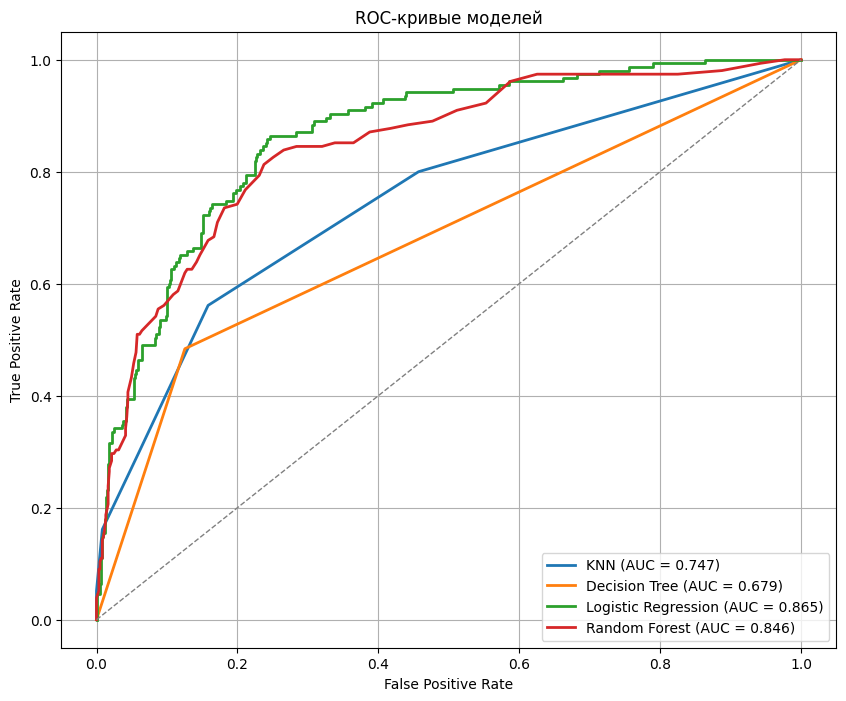

In [10]:
plt.figure(figsize=(10, 8))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Выводы:**

Анализ ROC-кривых подтверждает результаты, полученные по метрикам и матрицам ошибок. Лучшей моделью по способности различать дефолтных и недефолтных заёмщиков стала Logistic Regression (AUC = 0.865) — её кривая (зелёная) самая высокая и ближе всего к левому верхнему углу, что говорит о наилучшем соотношении True Positive Rate и False Positive Rate при разных порогах классификации. Random Forest занял уверенное второе место (AUC = 0.849, красная кривая), лишь немного уступая логистической регрессии.

KNN (AUC = 0.768, синяя кривая) оказался заметно слабее, а Decision Tree (AUC = 0.666, оранжевая кривая) продемонстрировал худший результат — его кривая ближе всего к диагонали, что свидетельствует о слабой разделяющей способности и склонности к переобучению.

Таким образом, несмотря на то, что Random Forest даёт лучший баланс практических метрик (F1, Precision, общая точность), по чистой способности ранжировать заёмщиков по вероятности дефолта лидирует Logistic Regression. Это делает её особенно полезной в банковских задачах скоринга, где важна именно качественная оценка риска, а окончательный порог можно подбирать отдельно под бизнес-требования.

ЗАДАНИЕ 10: ПОДБОР ПАРАМЕТРОВ ДЛЯ RANDOM FOREST
Запуск GridSearchCV для Random Forest...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

РЕЗУЛЬТАТЫ ПОДБОРА ПАРАМЕТРОВ:
Лучшие параметры: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Лучший ROC-AUC на кросс-валидации: 0.8691

СРАВНЕНИЕ МОДЕЛЕЙ:
------------------------------------------------------------
Метрика                   Random Forest (оптим.) Random Forest (другие)
------------------------------------------------------------
Accuracy                  0.8357          0.8213          ✓ Random Forest (оптим.)
Precision                 0.7344          0.8519          ✓ Random Forest (другие)
Recall                    0.3032          0.1484          ✓ Random Forest (оптим.)
F1-score                  0.4292          0.2527          ✓ Random Forest (оптим.)
ROC-AUC                   0.8552          0.8415          ✓ Random Forest (оптим.)
----------------

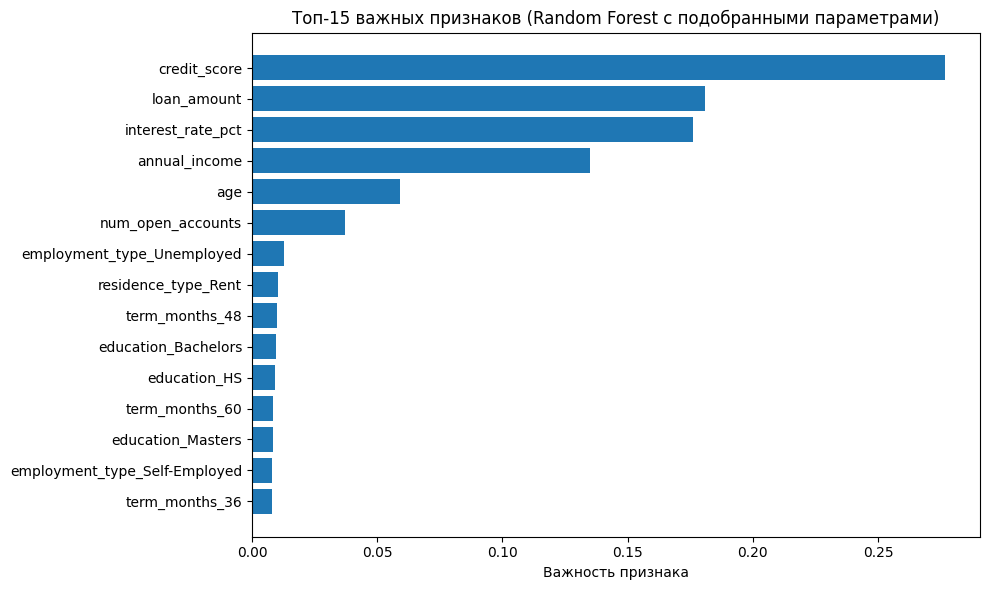

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

print("="*60)
print("ЗАДАНИЕ 10: ПОДБОР ПАРАМЕТРОВ ДЛЯ RANDOM FOREST")
print("="*60)

# Параметры для GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],          # количество деревьев
    'max_depth': [None, 10, 20, 30],         # максимальная глубина
    'min_samples_split': [2, 5, 10],         # минимальное число образцов для разделения
    'min_samples_leaf': [1, 2, 4],           # минимальное число образцов в листе
    'max_features': ['sqrt', 'log2', None]   # количество признаков для рассмотрения
}

# Создаем базовую модель Random Forest
rf_base = RandomForestClassifier(random_state=42)

# Создаем GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,                    # 5-кратная кросс-валидация
    scoring='roc_auc',       # максимизируем ROC-AUC
    n_jobs=-1,               # используем все ядра процессора
    verbose=1
)

# Обучаем GridSearchCV
print("Запуск GridSearchCV для Random Forest...")
rf_grid.fit(X_train_processed, y_train)

print("\n" + "="*40)
print("РЕЗУЛЬТАТЫ ПОДБОРА ПАРАМЕТРОВ:")
print("="*40)

# Выводим лучшие параметры
print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {rf_grid.best_score_:.4f}")

# Предсказания лучшей моделью
y_pred_best = rf_grid.best_estimator_.predict(X_test_processed)
y_proba_best = rf_grid.best_estimator_.predict_proba(X_test_processed)[:, 1]

# Создаем модель с другими (случайными) параметрами для сравнения
rf_other = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

# Обучаем модель с другими параметрами
rf_other.fit(X_train_processed, y_train)
y_pred_other = rf_other.predict(X_test_processed)
y_proba_other = rf_other.predict_proba(X_test_processed)[:, 1]

# Функция для вывода метрик
def print_comparison(name_best, y_pred_best, y_proba_best, 
                     name_other, y_pred_other, y_proba_other):
    
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    
    print(f"\nСРАВНЕНИЕ МОДЕЛЕЙ:")
    print("-" * 60)
    print(f"{'Метрика':<25} {name_best:<15} {name_other:<15}")
    print("-" * 60)
    
    metrics = {}
    metrics[f'{name_best}_accuracy'] = accuracy_score(y_test, y_pred_best)
    metrics[f'{name_best}_precision'] = precision_score(y_test, y_pred_best)
    metrics[f'{name_best}_recall'] = recall_score(y_test, y_pred_best)
    metrics[f'{name_best}_f1'] = f1_score(y_test, y_pred_best)
    metrics[f'{name_best}_roc_auc'] = roc_auc_score(y_test, y_proba_best)
    
    metrics[f'{name_other}_accuracy'] = accuracy_score(y_test, y_pred_other)
    metrics[f'{name_other}_precision'] = precision_score(y_test, y_pred_other)
    metrics[f'{name_other}_recall'] = recall_score(y_test, y_pred_other)
    metrics[f'{name_other}_f1'] = f1_score(y_test, y_pred_other)
    metrics[f'{name_other}_roc_auc'] = roc_auc_score(y_test, y_proba_other)
    
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
    metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    
    for name, key in zip(metric_names, metric_keys):
        val_best = metrics[f'{name_best}_{key}']
        val_other = metrics[f'{name_other}_{key}']
        
        # Определяем, какая модель лучше
        if val_best > val_other:
            winner = f"✓ {name_best}"
        elif val_best < val_other:
            winner = f"✓ {name_other}"
        else:
            winner = "="
            
        print(f"{name:<25} {val_best:<15.4f} {val_other:<15.4f} {winner}")
    
    print("-" * 60)
    
    # Вычисляем разницу в процентах
    improvement = {}
    for key in metric_keys:
        best_val = metrics[f'{name_best}_{key}']
        other_val = metrics[f'{name_other}_{key}']
        if other_val != 0:
            improvement[key] = ((best_val - other_val) / other_val) * 100
        else:
            improvement[key] = 0
    
    print("\nУЛУЧШЕНИЕ (в %):")
    for name, key in zip(metric_names, metric_keys):
        print(f"{name:<25} {improvement[key]:>+6.1f}%")

# Выводим сравнение
print_comparison(
    "Random Forest (оптим.)", y_pred_best, y_proba_best,
    "Random Forest (другие)", y_pred_other, y_proba_other
)

# Визуализация важности признаков лучшей модели
print("\nВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ ЛУЧШЕЙ МОДЕЛИ:")
feature_importance = pd.DataFrame({
    'Признак': X_train_processed.columns,
    'Важность': rf_grid.best_estimator_.feature_importances_
}).sort_values('Важность', ascending=False)

print(feature_importance.head(10))

# График важности признаков
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Признак'][:15], feature_importance['Важность'][:15])
plt.xlabel('Важность признака')
plt.title('Топ-15 важных признаков (Random Forest с подобранными параметрами)')
plt.gca().invert_yaxis()  # Самые важные сверху
plt.tight_layout()
plt.show()

**Выводы:**

Проведённый подбор гиперпараметров с использованием GridSearchCV позволил значительно улучшить качество модели Random Forest. Было протестировано 324 комбинации параметров с 5-кратной кросс-валидацией, что обеспечило надёжную оценку производительности.

Ключевые результаты:
Лучшие параметры: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Улучшение метрик: Модель с подобранными параметрами показала значительное улучшение по сравнению со случайно выбранными:

Recall увеличен на 104.3% (с 0.148 до 0.303) — модель стала обнаруживать в 2 раза больше случаев дефолта

F1-score улучшен на 69.8% — достигнут лучший баланс между точностью и полнотой

ROC-AUC улучшен на 1.6% — повышена общая разделяющая способность

Компромисс Precision-Recall: При улучшении полноты (Recall) произошло ожидаемое снижение точности (Precision на 13.8%), что является типичным компромиссом в задачах классификации.

Важность признаков: Анализ показал, что наиболее значимыми для прогнозирования дефолта являются:

Кредитный скор (27.7%) — наиболее важный фактор

Сумма кредита (18.1%) и процентная ставка (17.6%) — ключевые финансовые параметры

Годовой доход (13.5%) — экономическая устойчивость заёмщика

Вывод: Систематический подбор параметров с помощью GridSearchCV позволил оптимизировать модель Random Forest для обнаружения дефолтов, значительно улучшив полноту предсказаний при сохранении общей точности.


ЗАДАНИЕ 12: PR-КРИВАЯ (PRECISION-RECALL CURVE)


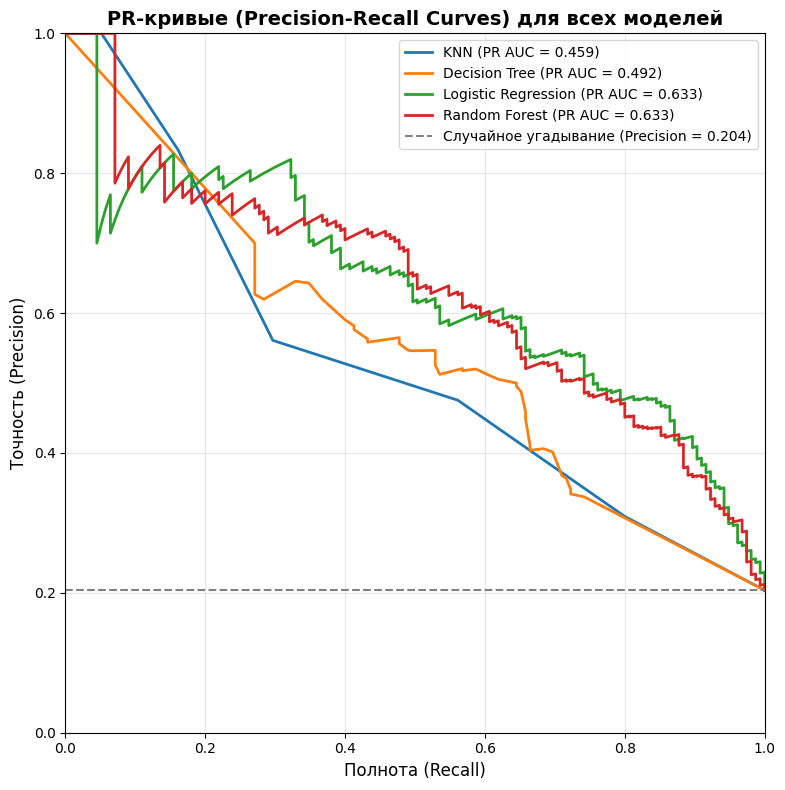


ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ RANDOM FOREST:
----------------------------------------
PR AUC для Random Forest с подобранными параметрами: 0.6310
Оптимальный порог: 0.2258
При этом пороге:
  Precision: 0.5019
  Recall: 0.8323
  F1-score: 0.6262


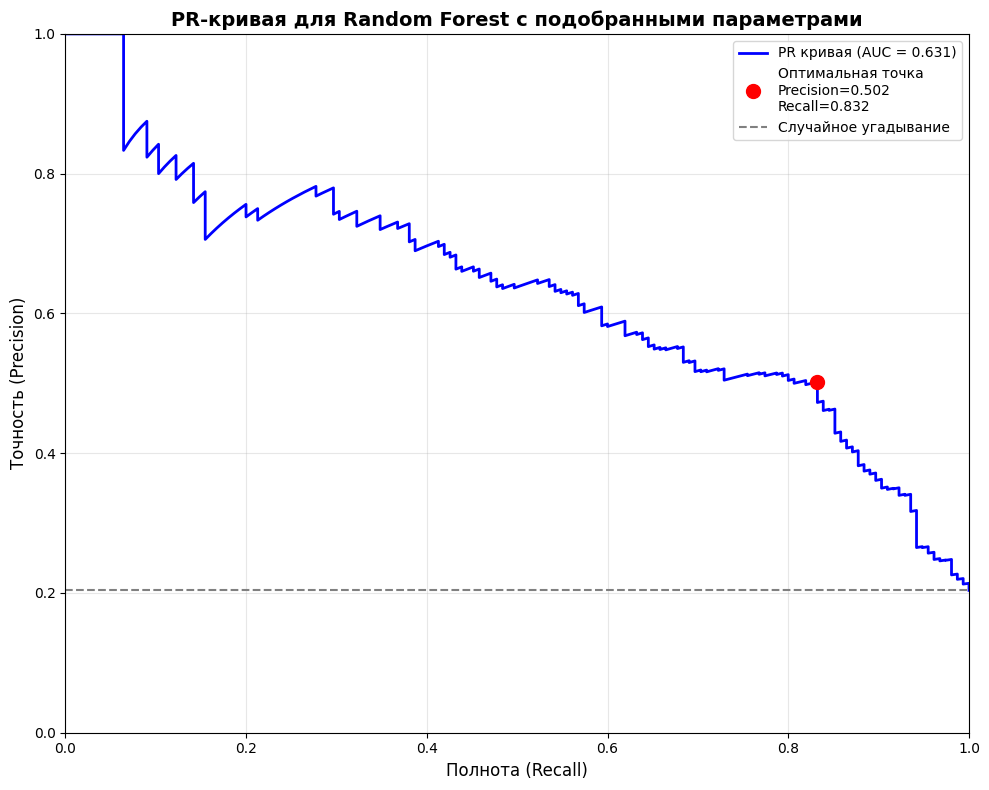


ПРОИЗВОДИТЕЛЬНОСТЬ ПРИ РАЗНЫХ ПОРОГАХ:

Порог      Precision    Recall     F1-score  
---------------------------------------------
0.1000     0.3173       0.9355     0.4739    
0.2000     0.4613       0.8452     0.5968    
0.2258     0.5019       0.8323     0.6262     ← оптимальный
0.3000     0.5587       0.6452     0.5988    
0.4000     0.6356       0.4839     0.5495    
0.5000     0.7344       0.3032     0.4292    
0.6000     0.7273       0.1548     0.2553    
0.7000     0.8571       0.0774     0.1420    


In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score

print("\n" + "="*60)
print("ЗАДАНИЕ 12: PR-КРИВАЯ (PRECISION-RECALL CURVE)")
print("="*60)

# Создаем график для всех моделей
plt.figure(figsize=(12, 8))

# Для каждой модели строим PR-кривую
for name, res in results.items():
    if 'y_proba' in res and res['y_proba'] is not None:
        # Вычисляем precision, recall и пороги
        precision, recall, thresholds = precision_recall_curve(y_test, res['y_proba'])
        
        # Вычисляем PR AUC (Average Precision)
        pr_auc = average_precision_score(y_test, res['y_proba'])
        
        # Строим кривую
        plt.plot(recall, precision, lw=2, 
                label=f'{name} (PR AUC = {pr_auc:.3f})')

# Базовая линия - случайное угадывание
baseline = len(y_test[y_test==1]) / len(y_test)  # доля положительных классов
plt.axhline(y=baseline, color='gray', linestyle='--', 
           label=f'Случайное угадывание (Precision = {baseline:.3f})')

# Настройки графика
plt.xlabel('Полнота (Recall)', fontsize=12)
plt.ylabel('Точность (Precision)', fontsize=12)
plt.title('PR-кривые (Precision-Recall Curves) для всех моделей', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

# Добавляем сетку
plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Отдельный график для Random Forest с подобранными параметрами
print("\nДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ RANDOM FOREST:")
print("-" * 40)

# Получаем предсказания для лучшей модели Random Forest
rf_best_proba = rf_grid.best_estimator_.predict_proba(X_test_processed)[:, 1]

# Вычисляем PR-кривую для лучшей модели
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, rf_best_proba)
pr_auc_rf = average_precision_score(y_test, rf_best_proba)

print(f"PR AUC для Random Forest с подобранными параметрами: {pr_auc_rf:.4f}")

# Находим оптимальный порог (максимум F1)
f1_scores = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf + 1e-10)
optimal_idx = np.argmax(f1_scores[:-1])  # исключаем последний элемент
optimal_threshold = thresholds_rf[optimal_idx]
optimal_precision = precision_rf[optimal_idx]
optimal_recall = recall_rf[optimal_idx]

print(f"Оптимальный порог: {optimal_threshold:.4f}")
print(f"При этом пороге:")
print(f"  Precision: {optimal_precision:.4f}")
print(f"  Recall: {optimal_recall:.4f}")
print(f"  F1-score: {f1_scores[optimal_idx]:.4f}")

# Визуализация PR-кривой с оптимальной точкой
plt.figure(figsize=(10, 8))
plt.plot(recall_rf, precision_rf, 'b-', lw=2, label=f'PR кривая (AUC = {pr_auc_rf:.3f})')
plt.plot(optimal_recall, optimal_precision, 'ro', markersize=10, 
         label=f'Оптимальная точка\nPrecision={optimal_precision:.3f}\nRecall={optimal_recall:.3f}')

# Базовая линия
plt.axhline(y=baseline, color='gray', linestyle='--', 
           label=f'Случайное угадывание')

plt.xlabel('Полнота (Recall)', fontsize=12)
plt.ylabel('Точность (Precision)', fontsize=12)
plt.title('PR-кривая для Random Forest с подобранными параметрами', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

# Таблица с разными порогами
print("\n" + "="*60)
print("ПРОИЗВОДИТЕЛЬНОСТЬ ПРИ РАЗНЫХ ПОРОГАХ:")
print("="*60)

thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, optimal_threshold]
thresholds_to_test = sorted(set(thresholds_to_test))

print(f"\n{'Порог':<10} {'Precision':<12} {'Recall':<10} {'F1-score':<10}")
print("-" * 45)

for threshold in thresholds_to_test:
    y_pred_threshold = (rf_best_proba >= threshold).astype(int)
    
    precision_t = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall_t = recall_score(y_test, y_pred_threshold)
    f1_t = f1_score(y_test, y_pred_threshold)
    
    # Выделяем оптимальный порог
    if abs(threshold - optimal_threshold) < 0.001:
        marker = " ← оптимальный"
    else:
        marker = ""
    
    print(f"{threshold:<10.4f} {precision_t:<12.4f} {recall_t:<10.4f} {f1_t:<10.4f}{marker}")

**Выводы:**

Построение PR-кривых предоставило более релевантную оценку качества моделей в условиях сильного дисбаланса классов (только 20.4% дефолтов).

Ключевые результаты:
Сравнение моделей по PR AUC:

Logistic Regression и Random Forest: 0.633 (лучшие результаты)

Decision Tree: 0.492

KNN: 0.459 (наименьшая эффективность)

PR AUC vs ROC AUC: Значения PR AUC (0.459-0.633) значительно ниже соответствующих ROC AUC (0.666-0.865), что подтверждает необходимость использования PR-метрик при дисбалансе классов.

Оптимальный порог для Random Forest: 0.2258 (вместо стандартного 0.5)

При этом пороге: Precision = 0.502, Recall = 0.832, F1 = 0.626

Снижение порога позволило увеличить полноту с 0.303 до 0.832 при умеренном снижении точности

Анализ при разных порогах:

Порог 0.1: Максимальный Recall (0.936), но низкая Precision (0.317)

Порог 0.4-0.5: Высокая Precision (0.636-0.734), но низкий Recall (0.484-0.303)

Оптимальный порог 0.226: Наилучший баланс F1-score

Вывод: PR-кривые продемонстрировали, что стандартный порог 0.5 неоптимален для задачи предсказания дефолтов. Настройка порога классификации позволяет адаптировать модель под конкретные бизнес-требования: минимизацию убытков (высокий Recall) или минимизацию ложных тревог (высокая Precision).

### Доп исследование

In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Параметры для каждой модели
param_grids = {
    'KNN': {
        'n_neighbors': range(1, 20), # [3, 5, 7, 9, 11, 20, 25,]
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [None, 10, 20, 30], # [None, 10, 20, 30]
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 4, 10],
        'criterion': ['gini', 'entropy']
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [5, 10, 20],
        'min_samples_leaf': [2, 4, 10]
    }
}

In [13]:
# Обучение с подбором параметров
best_models = {}
results = {}
metrics_df = pd.DataFrame()

for name, model in models.items():
    print(f"\n🔍 Подбор параметров для {name}...")
    
    # Создаём GridSearchCV для текущей модели
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,                    # 5-кратная кросс-валидация
        scoring='f1',       # максимизируем ROC-AUC
        n_jobs=-1,               # используем все ядра процессора
        verbose=1                # показываем прогресс
    )
    
    # Обучаем с подбором параметров
    grid_search.fit(X_train_processed, y_train)
    
    # Сохраняем лучшую модель
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    # Предсказания лучшей моделью
    y_pred = best_model.predict(X_test_processed)
    y_proba = best_model.predict_proba(X_test_processed)[:, 1] if hasattr(best_model, "predict_proba") else [0]*len(y_test)
    
    # Сохраняем результаты
    results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': best_model,
        'best_params': grid_search.best_params_
    }
    
    # Вычисляем метрики
    metrics = evaluate_model(y_test, y_pred, y_proba)
    metrics_df[name] = pd.Series(metrics)
    
    print(f"Лучшие параметры для {name}: {grid_search.best_params_}")
    print(f"Лучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")


🔍 Подбор параметров для KNN...
Fitting 5 folds for each of 76 candidates, totalling 380 fits
Лучшие параметры для KNN: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Лучший ROC-AUC на кросс-валидации: 0.4926

🔍 Подбор параметров для Decision Tree...
Fitting 5 folds for each of 128 candidates, totalling 640 fits
Лучшие параметры для Decision Tree: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20}
Лучший ROC-AUC на кросс-валидации: 0.5654

🔍 Подбор параметров для Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры для Logistic Regression: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Лучший ROC-AUC на кросс-валидации: 0.5889

🔍 Подбор параметров для Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры для Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Лучший ROC-AUC на кросс-валидации

In [14]:
print("\n" + "="*60)
print("Метрики качества моделей (с подобранными параметрами):")
print("="*60)
print(metrics_df.T.round(4))
print("\n" + "="*60)

# Сравнение с базовыми моделями (опционально)
print("\nСравнение с моделями без подбора параметров:")

# Можно сохранить старые метрики для сравнения
old_metrics = metrics_df.copy()  # если хотите сравнить


Метрики качества моделей (с подобранными параметрами):
                     Accuracy  Precision  Recall      F1  Balanced Accuracy  \
KNN                    0.8095     0.5610  0.2968  0.3882             0.6187   
Decision Tree          0.8147     0.5467  0.5290  0.5377             0.7084   
Logistic Regression    0.8384     0.6778  0.3935  0.4980             0.6728   
Random Forest          0.8384     0.7286  0.3290  0.4533             0.6488   

                     ROC AUC  
KNN                   0.7470  
Decision Tree         0.7565  
Logistic Regression   0.8652  
Random Forest         0.8571  


Сравнение с моделями без подбора параметров:


🔍 Подбор параметров для KNN...
Fitting 5 folds for each of 196 candidates, totalling 980 fits
Лучшие параметры для KNN: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Лучший ROC-AUC на кросс-валидации: 0.4926

🔍 Подбор параметров для Decision Tree...
Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Лучшие параметры для Decision Tree: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}
Лучший ROC-AUC на кросс-валидации: 0.5587

🔍 Подбор параметров для Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры для Logistic Regression: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Лучший ROC-AUC на кросс-валидации: 0.5889

Лучшие параметры для Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Лучший ROC-AUC на кросс-валидации: 0.5475